<a href="https://colab.research.google.com/github/AnuragKamblekar/Interncodes/blob/main/BasicAioperationonthebatteryandlocationdatasets23/4/2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

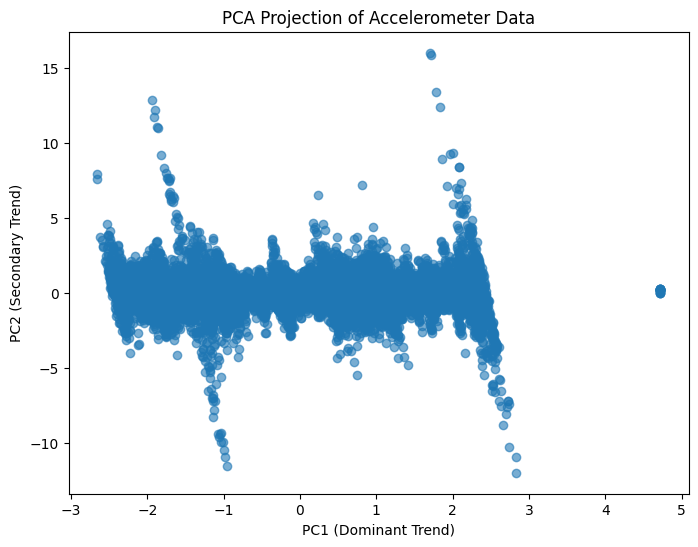

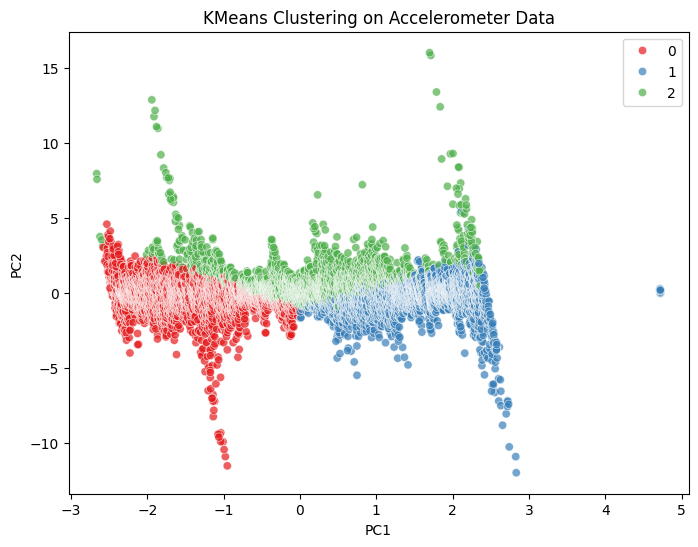

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv("Accelerometer.csv")

# Rename accelerometer columns if present
df = df.rename(columns={'x':'AccX','y':'AccY','z':'AccZ'})

# Step 2: Select numeric features
numeric_df = df.apply(pd.to_numeric, errors='coerce')
X_clean = numeric_df.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # Step 3: PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1 (Dominant Trend)")
    plt.ylabel("PC2 (Secondary Trend)")
    plt.title("PCA Projection of Accelerometer Data")
    plt.show()

    # Step 4: KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on Accelerometer Data")
    plt.show()

    # Step 5: Regression (if battery + location columns exist)
    if {'loc_speed','loc_altitude','battery_batteryLevel'}.issubset(df.columns):
        X_reg = df[['loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            print("Regression MSE:", mse)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Step 6: Classification (if lowPowerMode column exists)
    if 'battery_lowPowerMode' in df.columns:
        y_class = LabelEncoder().fit_transform(df['battery_lowPowerMode'].astype(str))
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()


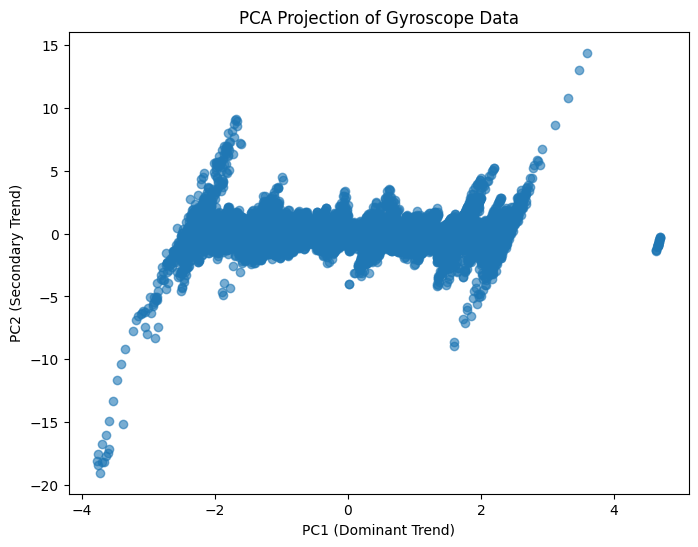

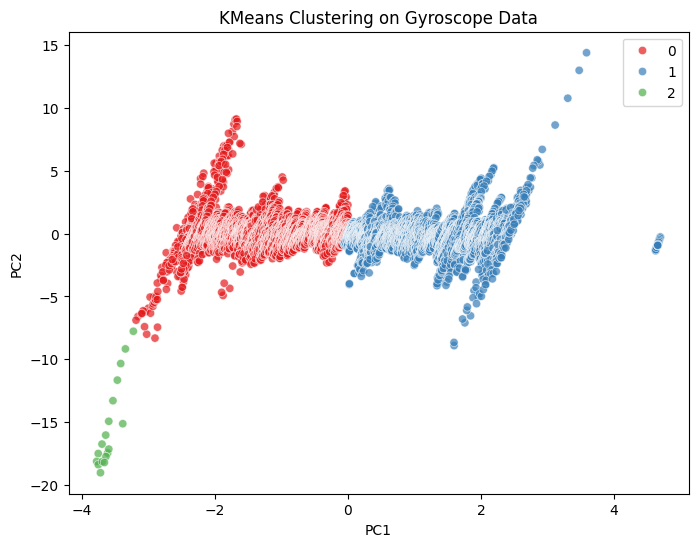

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv("Gyroscope.csv")

# Rename gyroscope columns if present
df = df.rename(columns={'x':'GyroX','y':'GyroY','z':'GyroZ'})

# Step 2: Select numeric features
numeric_df = df.apply(pd.to_numeric, errors='coerce')
X_clean = numeric_df.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # Step 3: PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1 (Dominant Trend)")
    plt.ylabel("PC2 (Secondary Trend)")
    plt.title("PCA Projection of Gyroscope Data")
    plt.show()

    # Step 4: KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on Gyroscope Data")
    plt.show()

    # Step 5: Regression (if battery + location columns exist)
    if {'loc_speed','loc_altitude','battery_batteryLevel'}.issubset(df.columns):
        X_reg = df[['loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            print("Regression MSE:", mse)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Step 6: Classification (if lowPowerMode column exists)
    if 'battery_lowPowerMode' in df.columns:
        y_class = LabelEncoder().fit_transform(df['battery_lowPowerMode'].astype(str))
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()


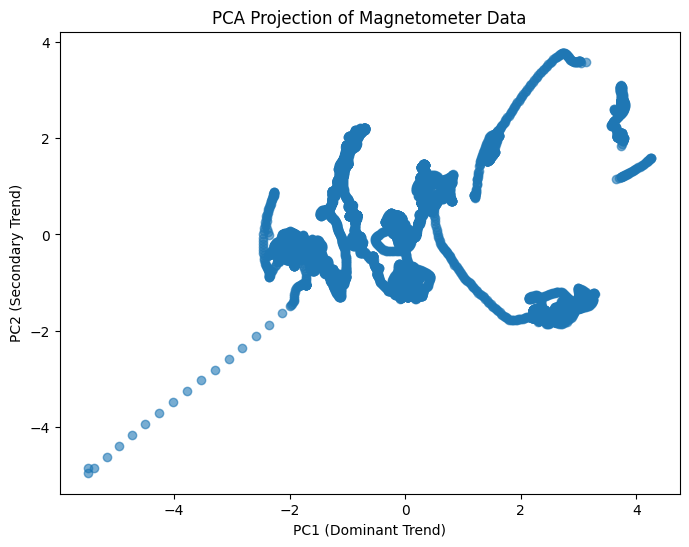

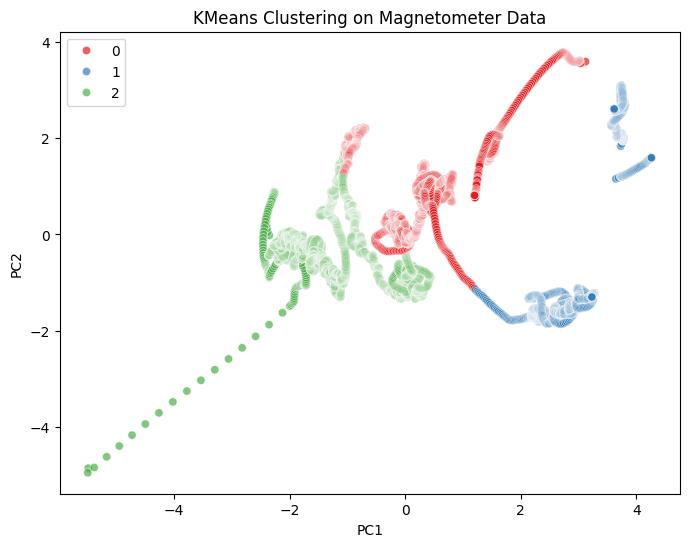

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv("Magnetometer.csv")

# Rename magnetometer columns if present
df = df.rename(columns={'x':'MagX','y':'MagY','z':'MagZ'})

# Step 2: Select numeric features
numeric_df = df.apply(pd.to_numeric, errors='coerce')
X_clean = numeric_df.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # Step 3: PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1 (Dominant Trend)")
    plt.ylabel("PC2 (Secondary Trend)")
    plt.title("PCA Projection of Magnetometer Data")
    plt.show()

    # Step 4: KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on Magnetometer Data")
    plt.show()

    # Step 5: Regression (if battery + location columns exist)
    if {'loc_speed','loc_altitude','battery_batteryLevel'}.issubset(df.columns):
        X_reg = df[['loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            print("Regression MSE:", mse)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Step 6: Classification (if lowPowerMode column exists)
    if 'battery_lowPowerMode' in df.columns:
        y_class = LabelEncoder().fit_transform(df['battery_lowPowerMode'].astype(str))
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()


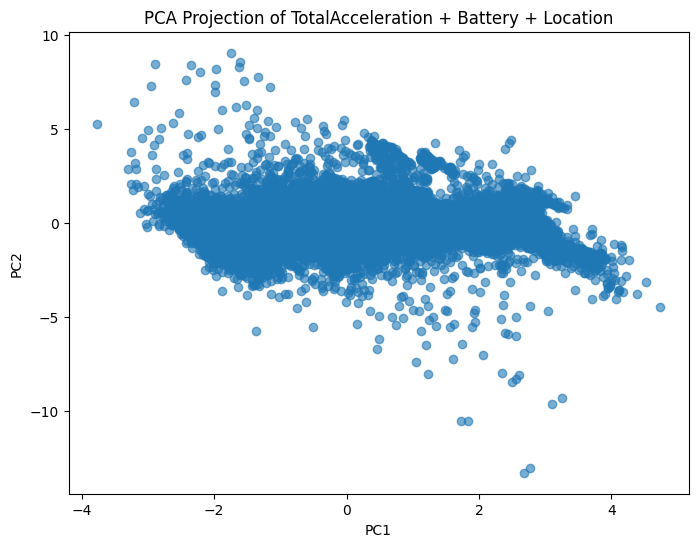

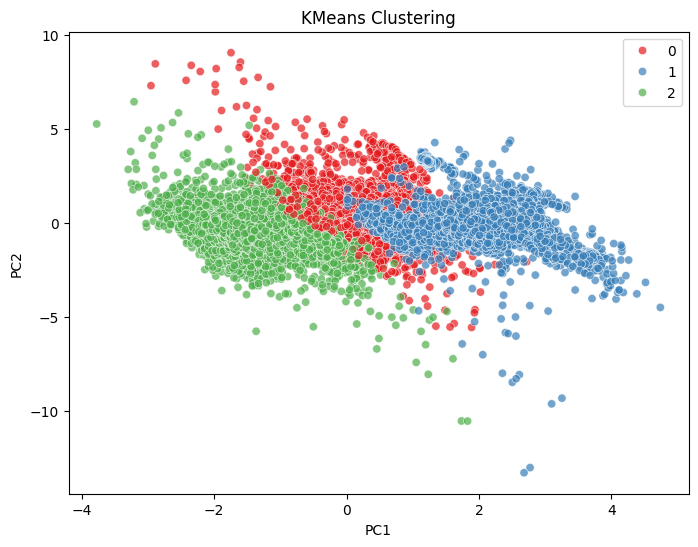

Silhouette Score (cluster quality): 0.22382766646132732
Regression MSE: 1.1539482493663454e-05
Regression RMSE: 0.0033969813796462666
Regression R²: 0.2308047526123881


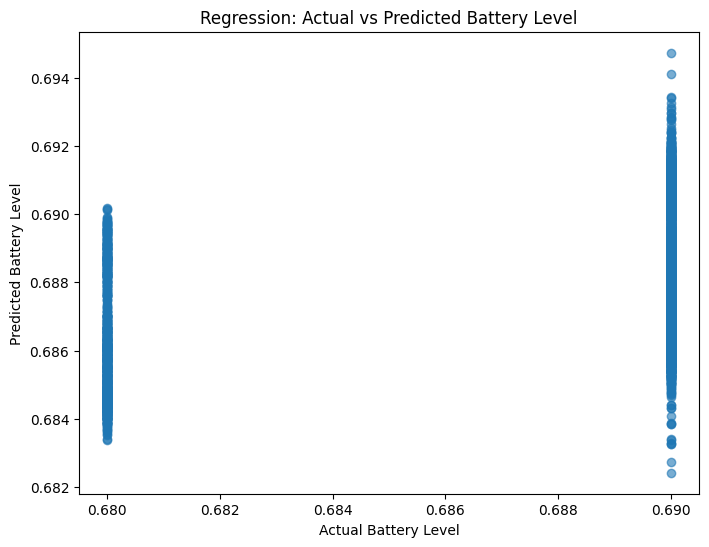

Classification skipped: only one class present in lowPowerMode.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, silhouette_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load datasets
totacc_df = pd.read_csv("TotalAcceleration.csv")
battery_df = pd.read_csv("Battery.csv")
location_df = pd.read_csv("Location.csv")

# Rename TotalAcceleration columns
totacc_df = totacc_df.rename(columns={'x':'TotalAccX','y':'TotalAccY','z':'TotalAccZ'})

# Step 2: Merge datasets on seconds_elapsed
merged_df = pd.merge_asof(
    pd.merge_asof(
        totacc_df.sort_values("seconds_elapsed"),
        battery_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed",
        direction="nearest"
    ),
    location_df.sort_values("seconds_elapsed"),
    on="seconds_elapsed",
    direction="nearest"
)

# Step 3: Select numeric features
features = ['TotalAccX','TotalAccY','TotalAccZ','batteryLevel','speed','altitude']
X = merged_df[features].apply(pd.to_numeric, errors='coerce').dropna()

# Step 4: PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of TotalAcceleration + Battery + Location")
plt.show()

# Step 5: KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
merged_df.loc[X.index,'cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering")
plt.show()

# Cluster evaluation
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score (cluster quality):", sil_score)

# Step 6: Regression (predict batteryLevel)
X_reg = merged_df[['TotalAccX','TotalAccY','TotalAccZ','speed','altitude']].apply(pd.to_numeric, errors='coerce').dropna()
y_reg = merged_df.loc[X_reg.index,'batteryLevel'].apply(pd.to_numeric, errors='coerce')

if not X_reg.empty and not y_reg.empty:
    X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
    reg_model = LinearRegression()
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("Regression MSE:", mse)
    print("Regression RMSE:", rmse)
    print("Regression R²:", r2)

    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Battery Level")
    plt.ylabel("Predicted Battery Level")
    plt.title("Regression: Actual vs Predicted Battery Level")
    plt.show()

# Step 7: Classification (predict lowPowerMode if >1 class exists)
if 'lowPowerMode' in merged_df.columns:
    y_class = LabelEncoder().fit_transform(merged_df['lowPowerMode'].astype(str))
    if len(np.unique(y_class)) > 1:
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        print("Classification Accuracy:", acc)
        print("Precision:", prec)
        print("Recall:", rec)
        print("F1-score:", f1)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()
    else:
        print("Classification skipped: only one class present in lowPowerMode.")


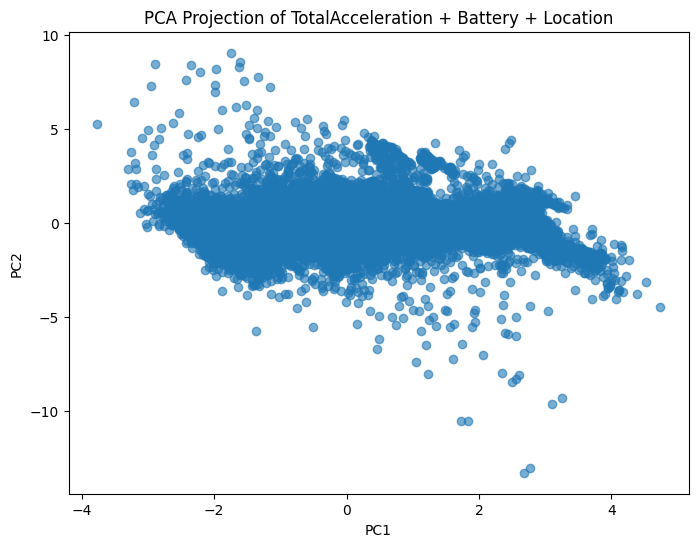

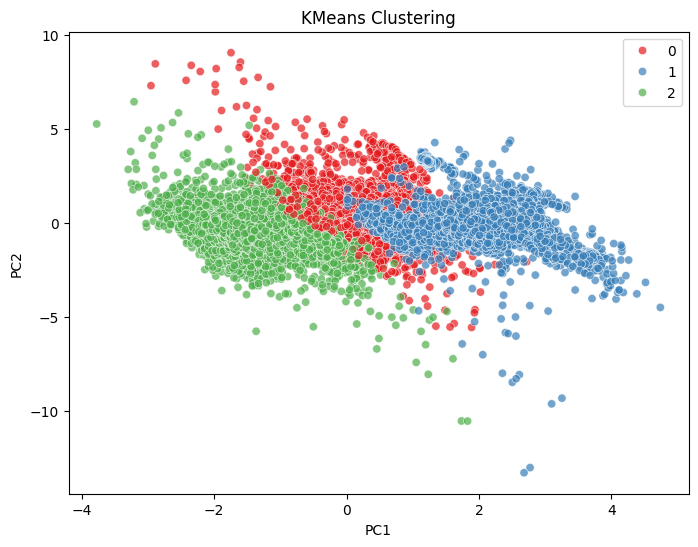

Regression MSE: 1.1539482493663454e-05
Regression RMSE: 0.0033969813796462666
Regression R²: 0.2308047526123881


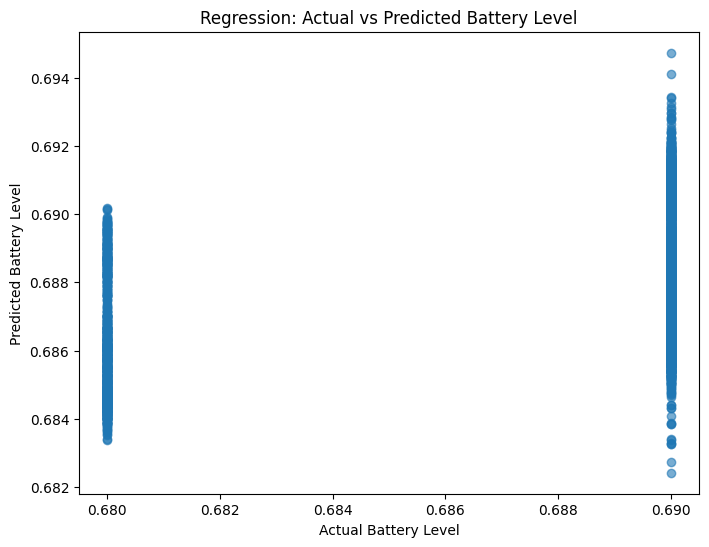

Classification skipped: only one class present in lowPowerMode.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Step 1: Load datasets
totacc_df = pd.read_csv("TotalAcceleration.csv")
battery_df = pd.read_csv("Battery.csv")
location_df = pd.read_csv("Location.csv")

# Rename TotalAcceleration columns
totacc_df = totacc_df.rename(columns={'x':'TotalAccX','y':'TotalAccY','z':'TotalAccZ'})

# Step 2: Merge datasets on seconds_elapsed
merged_df = pd.merge_asof(
    pd.merge_asof(
        totacc_df.sort_values("seconds_elapsed"),
        battery_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed",
        direction="nearest"
    ),
    location_df.sort_values("seconds_elapsed"),
    on="seconds_elapsed",
    direction="nearest"
)

# Step 3: Select numeric features
features = ['TotalAccX','TotalAccY','TotalAccZ','batteryLevel','speed','altitude']
X = merged_df[features].apply(pd.to_numeric, errors='coerce').dropna()

# Step 4: PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of TotalAcceleration + Battery + Location")
plt.show()

# Step 5: KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
merged_df.loc[X.index,'cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering")
plt.show()

# Step 6: Regression (predict batteryLevel)
X_reg = merged_df[['TotalAccX','TotalAccY','TotalAccZ','speed','altitude']].apply(pd.to_numeric, errors='coerce').dropna()
y_reg = merged_df.loc[X_reg.index,'batteryLevel'].apply(pd.to_numeric, errors='coerce')
if not X_reg.empty and not y_reg.empty:
    X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
    reg_model = LinearRegression()
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)

    from sklearn.metrics import mean_squared_error, r2_score
    import numpy as np

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("Regression MSE:", mse)
    print("Regression RMSE:", rmse)
    print("Regression R²:", r2)

    # Plot actual vs predicted
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Battery Level")
    plt.ylabel("Predicted Battery Level")
    plt.title("Regression: Actual vs Predicted Battery Level")
    plt.show()

# Step 7: Classification (predict lowPowerMode, only if >1 class exists)
if 'lowPowerMode' in merged_df.columns:
    y_class = LabelEncoder().fit_transform(merged_df['lowPowerMode'].astype(str))
    if len(np.unique(y_class)) > 1:  # Only run if at least 2 classes exist
        if len(y_class) >= len(X_scaled):
            y_class = y_class[:len(X_scaled)]
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print("Classification Accuracy:", acc)

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title("Classification Confusion Matrix (Low Power Mode)")
        plt.show()
    else:
        print("Classification skipped: only one class present in lowPowerMode.")


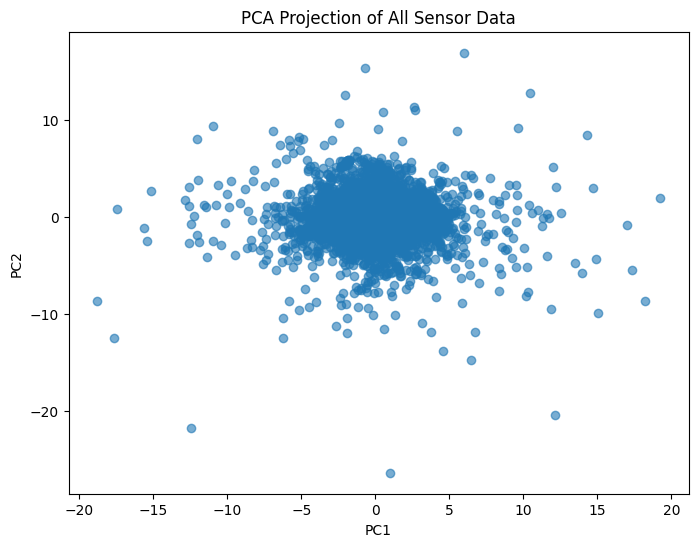

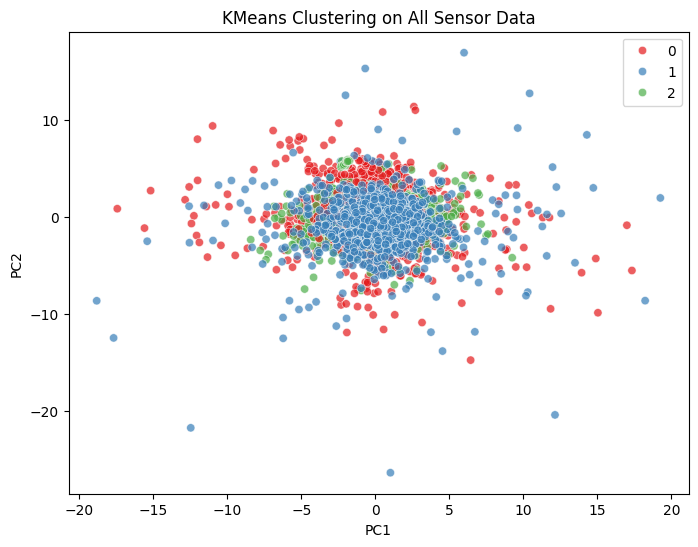

Silhouette Score: 0.1532596810810321
Regression MSE: 7.673799580086985e-08
Regression RMSE: 0.00027701623743179725
Regression R²: 0.05432967097468255


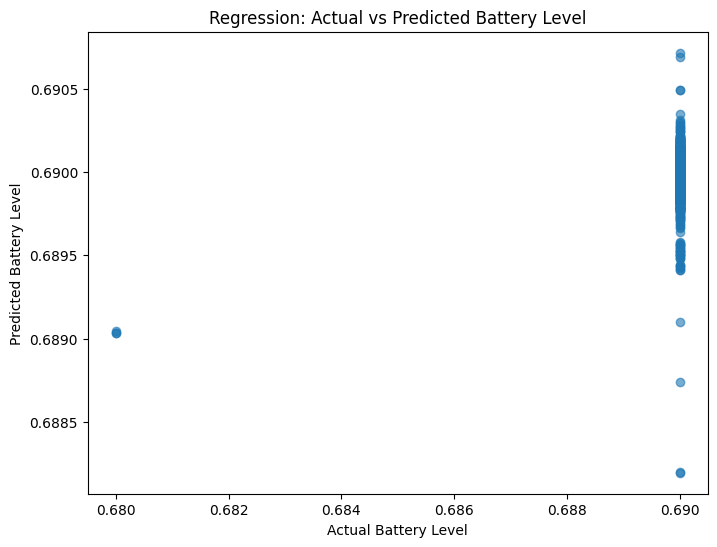

Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]

Degenerate Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467


--- ACC Classification Report ---
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467


--- GYRO Classification Report ---
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]
              precision    recall  f1-score   support

           0 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             silhouette_score, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

# Step 1: Load datasets
acc_df = pd.read_csv("Accelerometer.csv")
gyro_df = pd.read_csv("Gyroscope.csv")
mag_df = pd.read_csv("Magnetometer.csv")
totacc_df = pd.read_csv("TotalAcceleration.csv")
battery_df = pd.read_csv("Battery.csv")
location_df = pd.read_csv("Location.csv")

# Step 2: Add prefixes to avoid duplicate column names
def add_prefix(df, prefix):
    return df.rename(columns={col: f"{prefix}_{col}" for col in df.columns if col != "seconds_elapsed"})

acc_df = add_prefix(acc_df, "acc")
gyro_df = add_prefix(gyro_df, "gyro")
mag_df = add_prefix(mag_df, "mag")
totacc_df = add_prefix(totacc_df, "totacc")
battery_df = add_prefix(battery_df, "battery")
location_df = add_prefix(location_df, "loc")

# Step 3: Merge all datasets on seconds_elapsed
merged_df = pd.merge_asof(
    pd.merge_asof(
        pd.merge_asof(
            pd.merge_asof(
                pd.merge_asof(
                    acc_df.sort_values("seconds_elapsed"),
                    gyro_df.sort_values("seconds_elapsed"),
                    on="seconds_elapsed", direction="nearest"
                ),
                mag_df.sort_values("seconds_elapsed"),
                on="seconds_elapsed", direction="nearest"
            ),
            totacc_df.sort_values("seconds_elapsed"),
            on="seconds_elapsed", direction="nearest"
        ),
        battery_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed", direction="nearest"
    ),
    location_df.sort_values("seconds_elapsed"),
    on="seconds_elapsed", direction="nearest"
)

# Step 4: Select numeric features
features = [
    'acc_x','acc_y','acc_z',
    'gyro_x','gyro_y','gyro_z',
    'mag_x','mag_y','mag_z',
    'totacc_x','totacc_y','totacc_z',
    'battery_batteryLevel','loc_speed','loc_altitude'
]

X = merged_df[features].apply(pd.to_numeric, errors='coerce')
X_clean = X.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Projection of All Sensor Data")
    plt.show()

    # KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    merged_df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on All Sensor Data")
    plt.show()

    sil_score = silhouette_score(X_scaled, clusters)
    print("Silhouette Score:", sil_score)

    # Regression predicting battery level
    if 'battery_batteryLevel' in merged_df.columns:
        X_reg = merged_df[['acc_x','acc_y','acc_z',
                           'gyro_x','gyro_y','gyro_z',
                           'mag_x','mag_y','mag_z',
                           'totacc_x','totacc_y','totacc_z',
                           'loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = merged_df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')

        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)

            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred)

            print("Regression MSE:", mse)
            print("Regression RMSE:", rmse)
            print("Regression R²:", r2)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Classification on lowPowerMode (always produce report)
    if 'battery_lowPowerMode' in merged_df.columns:
        y_class = LabelEncoder().fit_transform(merged_df['battery_lowPowerMode'].astype(str))
        if len(np.unique(y_class)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class[:len(X_scaled)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            print("Classification Accuracy:", acc)
            print("Precision:", prec)
            print("Recall:", rec)
            print("F1-score:", f1)
            print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

            ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
            plt.title("Classification Confusion Matrix (Low Power Mode)")
            plt.show()
        else:
            print("Only one class present in lowPowerMode. Cannot train classifier.")
            print("Class distribution:", np.bincount(y_class))
            print("\nDegenerate Classification Report:\n", classification_report(y_class, y_class, zero_division=0))

# Step 9: Per-sensor classification reports
for sensor in ['acc','gyro','mag','totacc','loc']:
    cols = [c for c in merged_df.columns if c.startswith(sensor+'_')]
    if cols:
        X_sensor = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()
        if not X_sensor.empty:
            y_class = LabelEncoder().fit_transform(merged_df['battery_lowPowerMode'].astype(str))
            if len(np.unique(y_class)) > 1:
                X_train, X_test, y_train, y_test = train_test_split(X_sensor, y_class[:len(X_sensor)], test_size=0.2, random_state=42)
                clf = LogisticRegression(max_iter=1000)
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_test)

                print(f"\n--- {sensor.upper()} Classification Report ---")
                print("Accuracy:", accuracy_score(y_test, y_pred))
                print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
                print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
                print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
                print(classification_report(y_test, y_pred, zero_division=0))
            else:
                print(f"\n--- {sensor.upper()} Classification Report ---")
                print("Only one class present in lowPowerMode. Cannot train classifier.")
                print("Class distribution:", np.bincount(y_class))
                print(classification_report(y_class, y_class, zero_division=0))


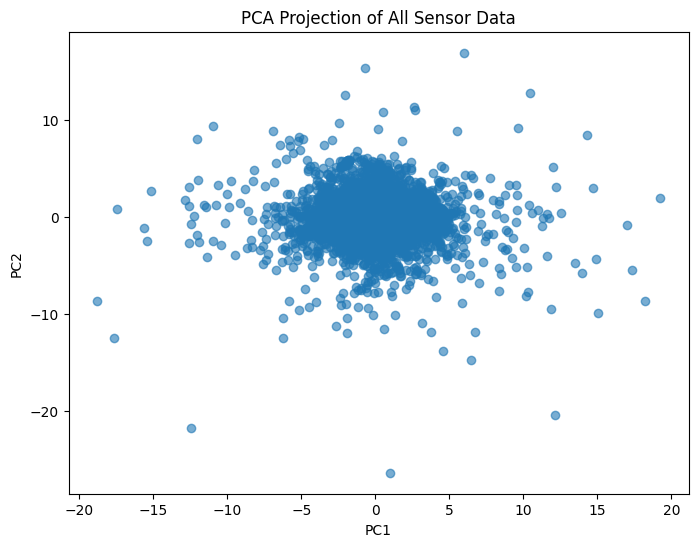

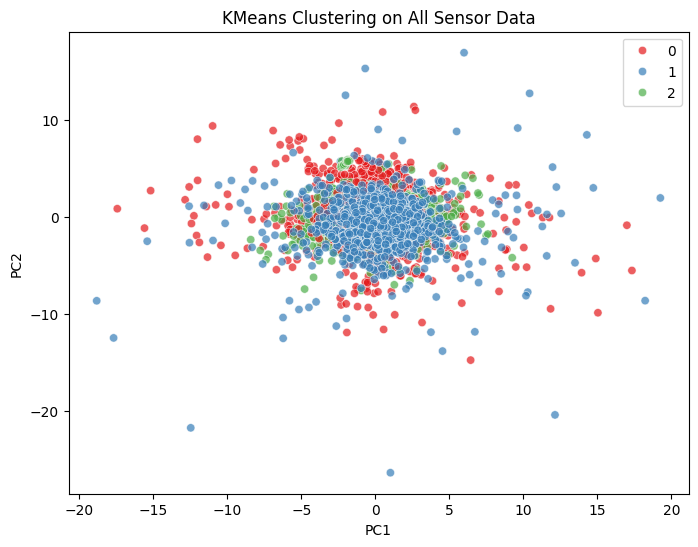

Silhouette Score: 0.1532596810810321
Regression MSE: 7.673799580086985e-08
Regression RMSE: 0.00027701623743179725
Regression R²: 0.05432967097468255


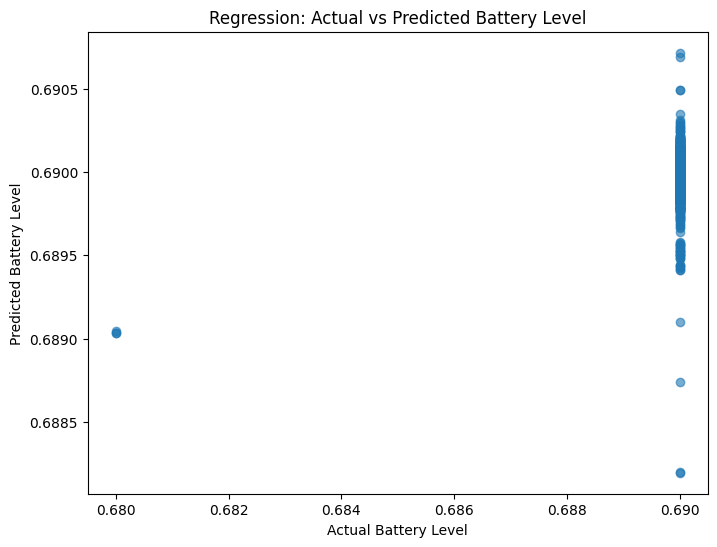


Motion Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       469
           1       0.99      1.00      1.00      2757
           2       0.94      0.95      0.95       111
           3       0.98      0.93      0.95       357

    accuracy                           0.99      3694
   macro avg       0.98      0.97      0.97      3694
weighted avg       0.99      0.99      0.99      3694



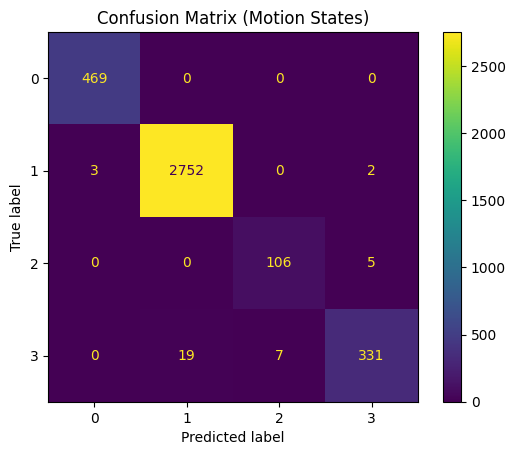

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             silhouette_score, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

# Step 1: Load datasets
acc_df = pd.read_csv("Accelerometer.csv")
gyro_df = pd.read_csv("Gyroscope.csv")
mag_df = pd.read_csv("Magnetometer.csv")
totacc_df = pd.read_csv("TotalAcceleration.csv")
battery_df = pd.read_csv("Battery.csv")
location_df = pd.read_csv("Location.csv")

# Step 2: Add prefixes to avoid duplicate column names
def add_prefix(df, prefix):
    return df.rename(columns={col: f"{prefix}_{col}" for col in df.columns if col != "seconds_elapsed"})

acc_df = add_prefix(acc_df, "acc")
gyro_df = add_prefix(gyro_df, "gyro")
mag_df = add_prefix(mag_df, "mag")
totacc_df = add_prefix(totacc_df, "totacc")
battery_df = add_prefix(battery_df, "battery")
location_df = add_prefix(location_df, "loc")

# Step 3: Merge all datasets on seconds_elapsed
merged_df = pd.merge_asof(
    pd.merge_asof(
        pd.merge_asof(
            pd.merge_asof(
                pd.merge_asof(
                    acc_df.sort_values("seconds_elapsed"),
                    gyro_df.sort_values("seconds_elapsed"),
                    on="seconds_elapsed", direction="nearest"
                ),
                mag_df.sort_values("seconds_elapsed"),
                on="seconds_elapsed", direction="nearest"
            ),
            totacc_df.sort_values("seconds_elapsed"),
            on="seconds_elapsed", direction="nearest"
        ),
        battery_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed", direction="nearest"
    ),
    location_df.sort_values("seconds_elapsed"),
    on="seconds_elapsed", direction="nearest"
)

# Step 4: Select numeric features
features = [
    'acc_x','acc_y','acc_z',
    'gyro_x','gyro_y','gyro_z',
    'mag_x','mag_y','mag_z',
    'totacc_x','totacc_y','totacc_z',
    'battery_batteryLevel','loc_speed','loc_altitude'
]

X = merged_df[features].apply(pd.to_numeric, errors='coerce')
X_clean = X.dropna()

if X_clean.empty:
    print("No numeric data available after cleaning.")
else:
    # PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Projection of All Sensor Data")
    plt.show()

    # KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    merged_df.loc[X_clean.index,'cluster'] = clusters

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clustering on All Sensor Data")
    plt.show()

    sil_score = silhouette_score(X_scaled, clusters)
    print("Silhouette Score:", sil_score)

    # Regression predicting battery level
    if 'battery_batteryLevel' in merged_df.columns:
        X_reg = merged_df[['acc_x','acc_y','acc_z',
                           'gyro_x','gyro_y','gyro_z',
                           'mag_x','mag_y','mag_z',
                           'totacc_x','totacc_y','totacc_z',
                           'loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = merged_df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')

        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression()
            reg_model.fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)

            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred)

            print("Regression MSE:", mse)
            print("Regression RMSE:", rmse)
            print("Regression R²:", r2)

            plt.figure(figsize=(8,6))
            plt.scatter(y_test, y_pred, alpha=0.6)
            plt.xlabel("Actual Battery Level")
            plt.ylabel("Predicted Battery Level")
            plt.title("Regression: Actual vs Predicted Battery Level")
            plt.show()

    # Classification using battery state
    if 'battery_batteryState' in merged_df.columns:
        y_class = LabelEncoder().fit_transform(merged_df['battery_batteryState'].astype(str))
        if len(np.unique(y_class)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class[:len(X_scaled)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            print("\nBattery State Classification Report:")
            print(classification_report(y_test, y_pred, zero_division=0))

            ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
            plt.title("Confusion Matrix (Battery State)")
            plt.show()

    # Motion classification from speed bins
    if 'loc_speed' in merged_df.columns:
        speed_bins = pd.cut(merged_df['loc_speed'], bins=[-0.1,0.5,3,10,100],
                            labels=['stationary','walking','running','driving'])
        y_motion = LabelEncoder().fit_transform(speed_bins.astype(str))
        if len(np.unique(y_motion)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_motion[:len(X_scaled)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            print("\nMotion Classification Report:")
            print(classification_report(y_test, y_pred, zero_division=0))

            ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
            plt.title("Confusion Matrix (Motion States)")
            plt.show()

# Step 9: Per-sensor classification reports + confusion matrices
for sensor in ['acc','gyro','mag','totacc','loc']:
    cols = [c for c in merged_df.columns if c.startswith(sensor+'_')]
    if cols and 'battery_batteryState' in merged_df.columns:
        X_sensor = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()
        y_class = LabelEncoder().fit_transform(merged_df['battery_batteryState'].astype(str))
        if not X_sensor.empty and len(np.unique(y_class)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_sensor, y_class[:len(X_sensor)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            print(f"\n--- {sensor.upper()} Classification Report ---")
            print(classification_report(y_test, y_pred, zero_division=0))

            ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
            plt.title(f"Confusion Matrix ({sensor.upper()})")
            plt.show()


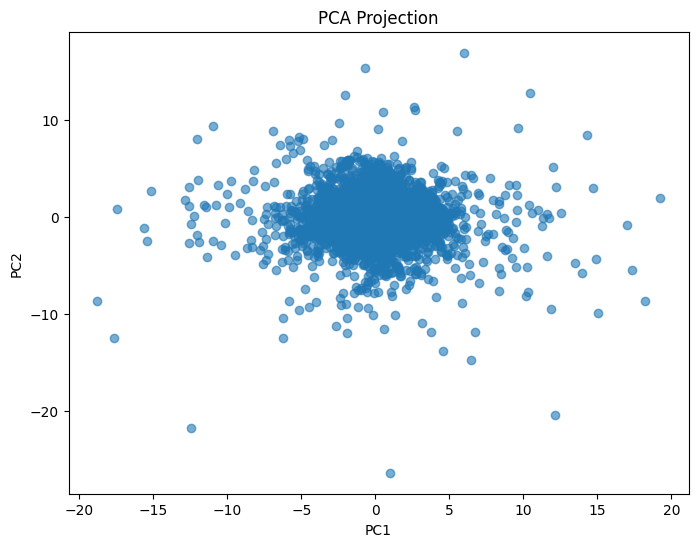

Silhouette Score: 0.1532596810810321
Regression MSE: 7.673799580086985e-08
Regression RMSE: 0.00027701623743179725
Regression R²: 0.05432967097468255
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]

Degenerate Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


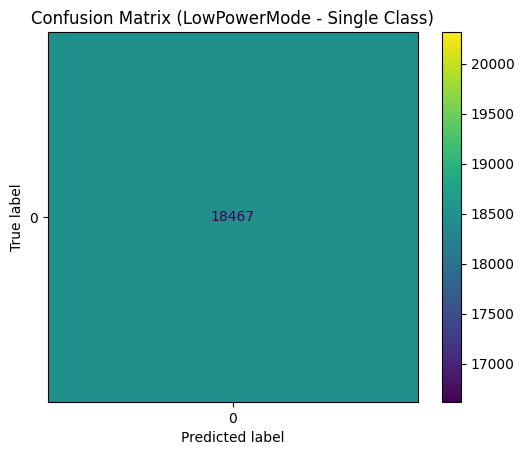


Motion Classification Report (with labels):
              precision    recall  f1-score   support

     driving       0.99      1.00      1.00       469
     running       0.99      1.00      1.00      2757
  stationary       0.94      0.95      0.95       111
     walking       0.98      0.93      0.95       357

    accuracy                           0.99      3694
   macro avg       0.98      0.97      0.97      3694
weighted avg       0.99      0.99      0.99      3694



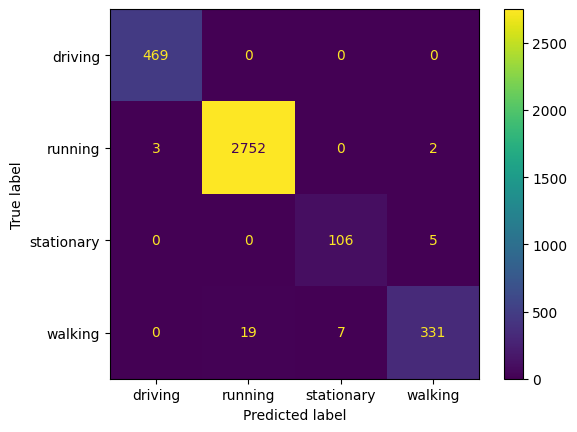

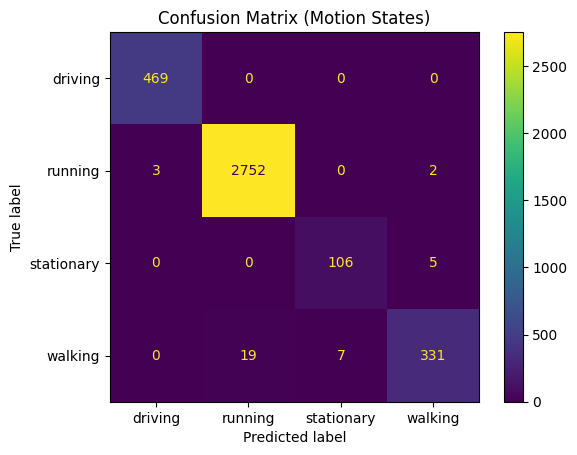


--- ACC Classification Report ---
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


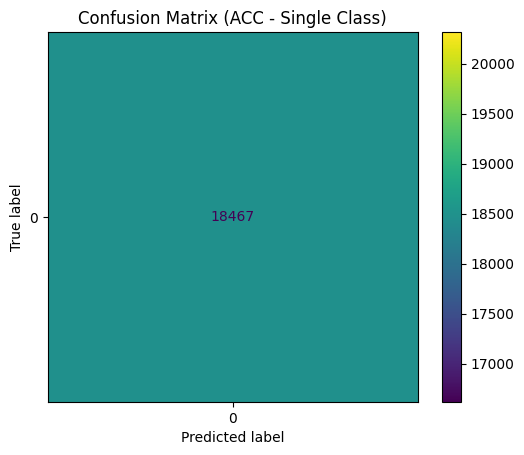


--- GYRO Classification Report ---
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


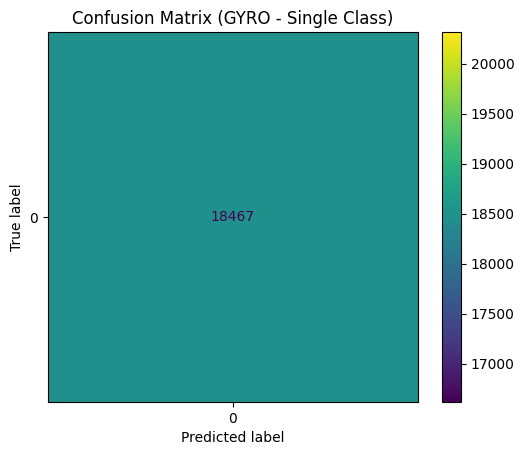


--- MAG Classification Report ---
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


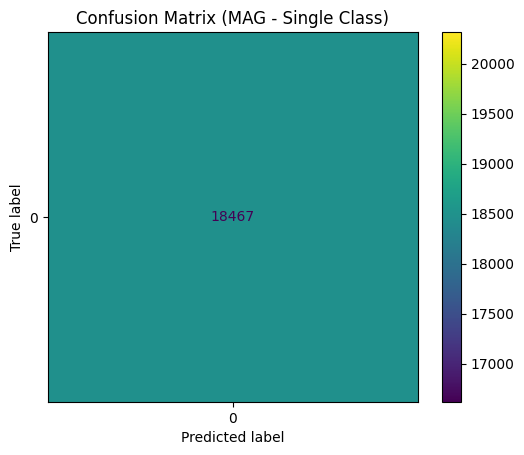


--- TOTACC Classification Report ---
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


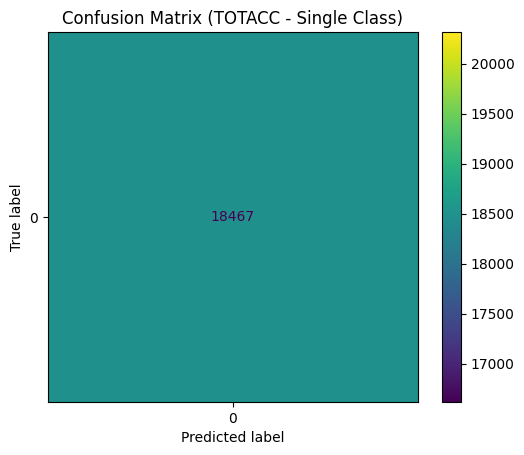


--- LOC Classification Report ---
Only one class present in lowPowerMode. Cannot train classifier.
Class distribution: [18467]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18467

    accuracy                           1.00     18467
   macro avg       1.00      1.00      1.00     18467
weighted avg       1.00      1.00      1.00     18467



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


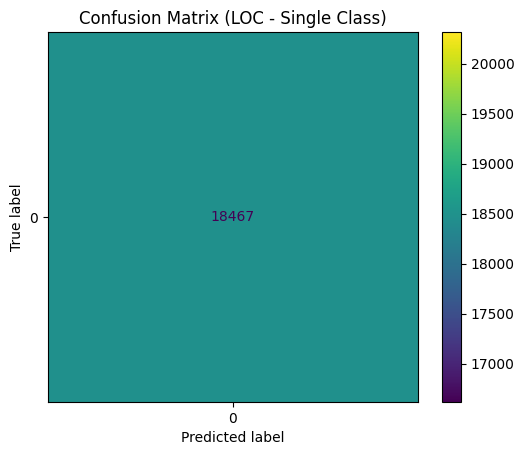

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             silhouette_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

# Step 1: Load datasets
acc_df = pd.read_csv("Accelerometer.csv")
gyro_df = pd.read_csv("Gyroscope.csv")
mag_df = pd.read_csv("Magnetometer.csv")
totacc_df = pd.read_csv("TotalAcceleration.csv")
battery_df = pd.read_csv("Battery.csv")
location_df = pd.read_csv("Location.csv")

# Step 2: Add prefixes
def add_prefix(df, prefix):
    return df.rename(columns={col: f"{prefix}_{col}" for col in df.columns if col != "seconds_elapsed"})

acc_df = add_prefix(acc_df, "acc")
gyro_df = add_prefix(gyro_df, "gyro")
mag_df = add_prefix(mag_df, "mag")
totacc_df = add_prefix(totacc_df, "totacc")
battery_df = add_prefix(battery_df, "battery")
location_df = add_prefix(location_df, "loc")

# Step 3: Merge datasets
merged_df = pd.merge_asof(
    pd.merge_asof(
        pd.merge_asof(
            pd.merge_asof(
                pd.merge_asof(
                    acc_df.sort_values("seconds_elapsed"),
                    gyro_df.sort_values("seconds_elapsed"),
                    on="seconds_elapsed", direction="nearest"
                ),
                mag_df.sort_values("seconds_elapsed"),
                on="seconds_elapsed", direction="nearest"
            ),
            totacc_df.sort_values("seconds_elapsed"),
            on="seconds_elapsed", direction="nearest"
        ),
        battery_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed", direction="nearest"
    ),
    location_df.sort_values("seconds_elapsed"),
    on="seconds_elapsed", direction="nearest"
)

# Step 4: Features
features = [
    'acc_x','acc_y','acc_z',
    'gyro_x','gyro_y','gyro_z',
    'mag_x','mag_y','mag_z',
    'totacc_x','totacc_y','totacc_z',
    'battery_batteryLevel','loc_speed','loc_altitude'
]

X = merged_df[features].apply(pd.to_numeric, errors='coerce')
X_clean = X.dropna()

if not X_clean.empty:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA Projection")
    plt.show()

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    merged_df.loc[X_clean.index,'cluster'] = clusters
    sil_score = silhouette_score(X_scaled, clusters)
    print("Silhouette Score:", sil_score)

    # Regression
    if 'battery_batteryLevel' in merged_df.columns:
        X_reg = merged_df[['acc_x','acc_y','acc_z',
                           'gyro_x','gyro_y','gyro_z',
                           'mag_x','mag_y','mag_z',
                           'totacc_x','totacc_y','totacc_z',
                           'loc_speed','loc_altitude']].apply(pd.to_numeric, errors='coerce').dropna()
        y_reg = merged_df.loc[X_reg.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not X_reg.empty and not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression().fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            print("Regression MSE:", mean_squared_error(y_test, y_pred))
            print("Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
            print("Regression R²:", r2_score(y_test, y_pred))

    # LowPowerMode classification (degenerate handling)
    if 'battery_lowPowerMode' in merged_df.columns:
        y_class = LabelEncoder().fit_transform(merged_df['battery_lowPowerMode'].astype(str))
        if len(np.unique(y_class)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class[:len(X_scaled)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            print("\nLowPowerMode Classification Report:")
            print(classification_report(y_test, y_pred, zero_division=0))
            ConfusionMatrixDisplay.from_predictions(y_test, y_pred).plot()
            plt.title("Confusion Matrix (LowPowerMode)")
            plt.show()
        else:
            print("Only one class present in lowPowerMode. Cannot train classifier.")
            print("Class distribution:", np.bincount(y_class))
            print("\nDegenerate Classification Report:")
            print(classification_report(y_class, y_class, zero_division=0))
            cm = confusion_matrix(y_class, y_class)
            ConfusionMatrixDisplay(confusion_matrix=cm).plot()
            plt.title("Confusion Matrix (LowPowerMode - Single Class)")
            plt.show()

    # Motion classification with labels
    if 'loc_speed' in merged_df.columns:
        speed_bins = pd.cut(merged_df['loc_speed'], bins=[-0.1,0.5,3,10,100],
                            labels=['stationary','walking','running','driving'])
        encoder = LabelEncoder()
        y_motion = encoder.fit_transform(speed_bins.astype(str))
        class_labels = list(encoder.classes_)
        if len(np.unique(y_motion)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_motion[:len(X_scaled)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            print("\nMotion Classification Report (with labels):")
            print(classification_report(y_test, y_pred, target_names=class_labels, zero_division=0))
            ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_labels).plot()
            plt.title("Confusion Matrix (Motion States)")
            plt.show()

# Step 9: Per-sensor classification reports
for sensor in ['acc','gyro','mag','totacc','loc']:
    cols = [c for c in merged_df.columns if c.startswith(sensor+'_')]
    if cols and 'battery_lowPowerMode' in merged_df.columns:
        X_sensor = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()
        y_class = LabelEncoder().fit_transform(merged_df['battery_lowPowerMode'].astype(str))
        if not X_sensor.empty:
            if len(np.unique(y_class)) > 1:
                X_train, X_test, y_train, y_test = train_test_split(X_sensor, y_class[:len(X_sensor)], test_size=0.2, random_state=42)
                clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
                y_pred = clf.predict(X_test)
                print(f"\n--- {sensor.upper()} Classification Report ---")
                print(classification_report(y_test, y_pred, zero_division=0))
                ConfusionMatrixDisplay.from_predictions(y_test, y_pred).plot()
                plt.title(f"Confusion Matrix ({sensor.upper()})")
                plt.show()
            else:
                print(f"\n--- {sensor.upper()} Classification Report ---")
                print("Only one class present in lowPowerMode. Cannot train classifier.")
                print("Class distribution:", np.bincount(y_class))
                print(classification_report(y_class, y_class, zero_division=0))
                cm = confusion_matrix(y_class, y_class)
                ConfusionMatrixDisplay(confusion_matrix=cm).plot()
                plt.title(f"Confusion Matrix ({sensor.upper()} - Single Class)")
                plt.show()


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, silhouette_score)
from sklearn.model_selection import train_test_split

def run_sensor_analysis(acc_df, gyro_df, mag_df, totacc_df, battery_df, location_df):
    # Prefix helper
    def add_prefix(df, prefix):
        return df.rename(columns={col: f"{prefix}_{col}" for col in df.columns if col != "seconds_elapsed"})

    acc_df = add_prefix(acc_df, "acc")
    gyro_df = add_prefix(gyro_df, "gyro")
    mag_df = add_prefix(mag_df, "mag")
    totacc_df = add_prefix(totacc_df, "totacc")
    battery_df = add_prefix(battery_df, "battery")
    location_df = add_prefix(location_df, "loc")

    # Merge all datasets
    merged_df = pd.merge_asof(
        pd.merge_asof(
            pd.merge_asof(
                pd.merge_asof(
                    pd.merge_asof(
                        acc_df.sort_values("seconds_elapsed"),
                        gyro_df.sort_values("seconds_elapsed"),
                        on="seconds_elapsed", direction="nearest"
                    ),
                    mag_df.sort_values("seconds_elapsed"),
                    on="seconds_elapsed", direction="nearest"
                ),
                totacc_df.sort_values("seconds_elapsed"),
                on="seconds_elapsed", direction="nearest"
            ),
            battery_df.sort_values("seconds_elapsed"),
            on="seconds_elapsed", direction="nearest"
        ),
        location_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed", direction="nearest"
    )

    # Features
    features = [
        'acc_x','acc_y','acc_z',
        'gyro_x','gyro_y','gyro_z',
        'mag_x','mag_y','mag_z',
        'totacc_x','totacc_y','totacc_z',
        'battery_batteryLevel','loc_speed','loc_altitude'
    ]
    X = merged_df[features].apply(pd.to_numeric, errors='coerce').dropna()

    if X.empty:
        print("No numeric data available after cleaning.")
        return

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA Projection")
    plt.show()

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    merged_df.loc[X.index,'cluster'] = clusters
    print("Silhouette Score:", silhouette_score(X_scaled, clusters))

    # Regression on battery level
    if 'battery_batteryLevel' in merged_df.columns:
        y_reg = merged_df.loc[X.index,'battery_batteryLevel'].apply(pd.to_numeric, errors='coerce')
        if not y_reg.empty:
            X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
            reg_model = LinearRegression().fit(X_train, y_train)
            y_pred = reg_model.predict(X_test)
            print("Regression MSE:", mean_squared_error(y_test, y_pred))
            print("Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
            print("Regression R²:", r2_score(y_test, y_pred))

    # Helper for classification + confusion matrix
    def classify_and_report(X_data, y_data, title, labels=None):
        if len(np.unique(y_data)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_data, y_data[:len(X_data)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            print(f"\n{title} Classification Report:")
            print(classification_report(y_test, y_pred, target_names=labels if labels else None, zero_division=0))
            ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=labels, cmap="plasma").plot()
            plt.title(f"Confusion Matrix ({title})")
            plt.show()
        else:
            print(f"\n{title} Classification Report:")
            print("Only one class present. Cannot train classifier.")
            print("Class distribution:", np.bincount(y_data))
            print(classification_report(y_data, y_data, target_names=labels if labels else None, zero_division=0))
            cm = confusion_matrix(y_data, y_data)
            ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels if labels else ["SingleClass"]).plot(cmap="plasma")
            plt.title(f"Confusion Matrix ({title} - Single Class)")
            plt.show()

    # LowPowerMode classification
    if 'battery_lowPowerMode' in merged_df.columns:
        y_class = LabelEncoder().fit_transform(merged_df['battery_lowPowerMode'].astype(str))
        classify_and_report(X_scaled, y_class, "LowPowerMode")

    # Motion classification with labels
    if 'loc_speed' in merged_df.columns:
        speed_bins = pd.cut(merged_df['loc_speed'], bins=[-0.1,0.5,3,10,100],
                            labels=['stationary','walking','running','driving'])
        encoder = LabelEncoder()
        y_motion = encoder.fit_transform(speed_bins.astype(str))
        class_labels = list(encoder.classes_)
        classify_and_report(X_scaled, y_motion, "Motion States", labels=class_labels)

    # Per-sensor classification reports
    for sensor in ['acc','gyro','mag','totacc','loc']:
        cols = [c for c in merged_df.columns if c.startswith(sensor+'_')]
        if cols and 'battery_lowPowerMode' in merged_df.columns:
            X_sensor = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()
            y_class = LabelEncoder().fit_transform(merged_df['battery_lowPowerMode'].astype(str))
            classify_and_report(X_sensor, y_class, sensor.upper())
run_sensor_analysis(acc_df, gyro_df, mag_df, totacc_df, battery_df, location_df)


KeyError: "None of [Index(['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x',\n       'mag_y', 'mag_z', 'totacc_x', 'totacc_y', 'totacc_z',\n       'battery_batteryLevel', 'loc_speed', 'loc_altitude'],\n      dtype='object')] are in the [columns]"

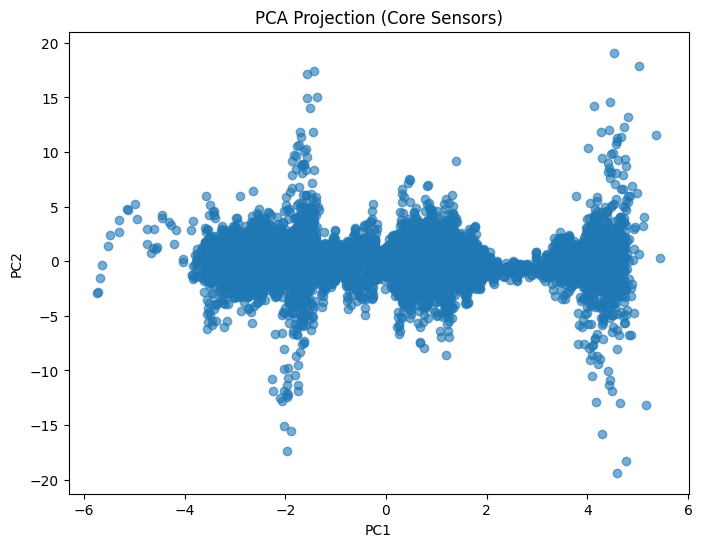

Silhouette Score: 0.12334506283636243

ACC Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



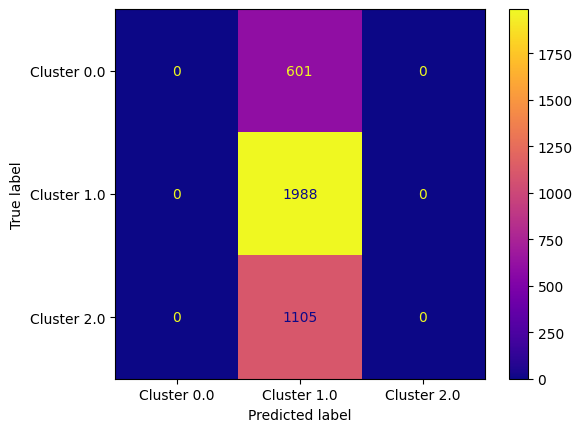

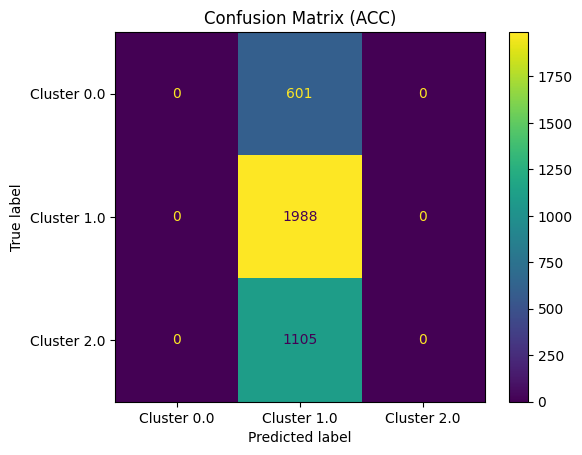


GYRO Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



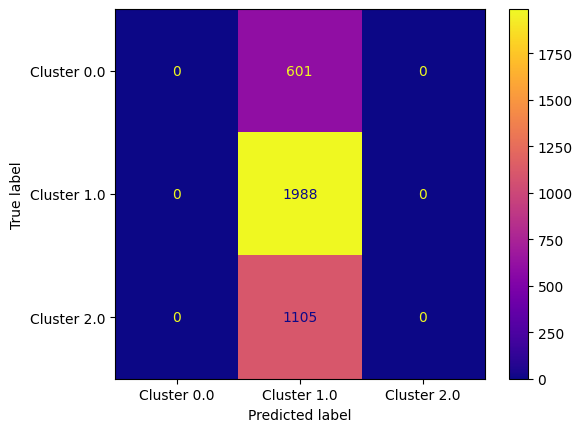

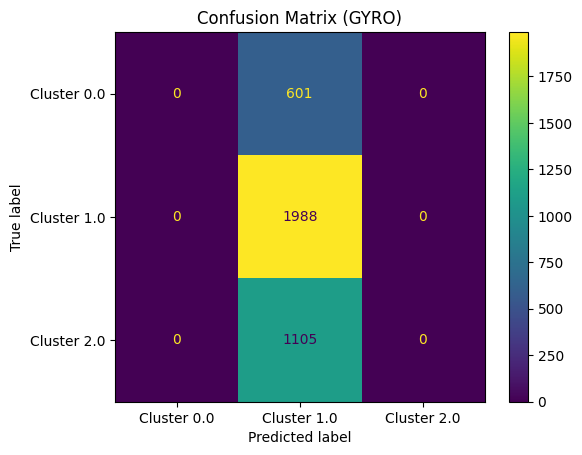


MAG Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



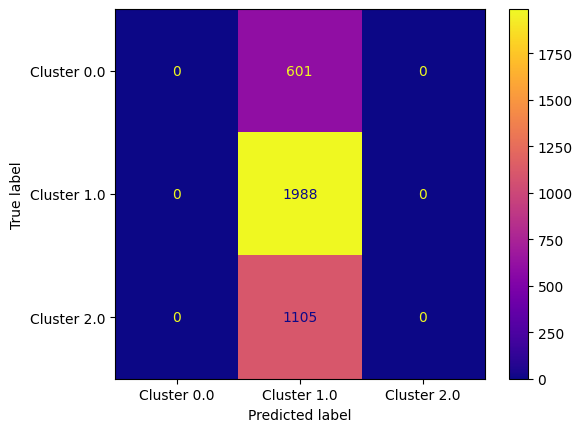

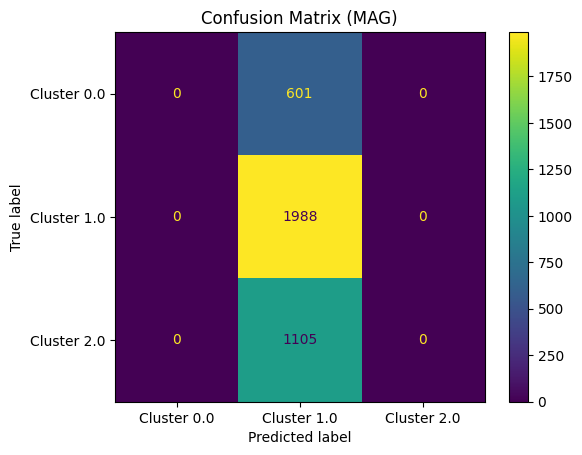


TOTACC Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



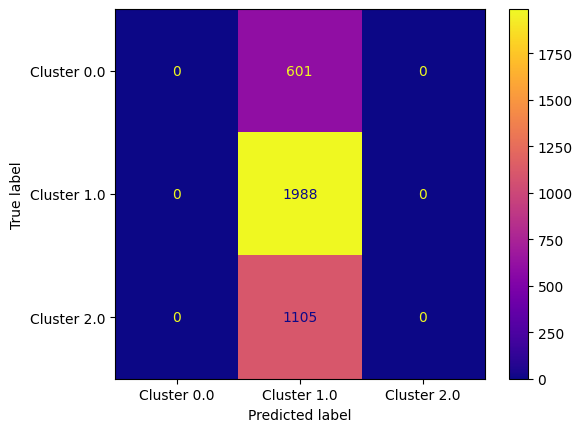

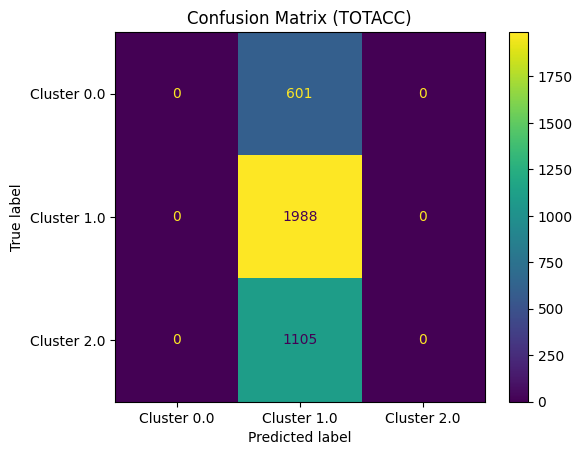

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.model_selection import train_test_split

def run_core_sensor_analysis(acc_df, gyro_df, mag_df, totacc_df):
    # Normalize column names
    def normalize_axes(df, prefix):
        cols = list(df.columns)
        mapping = {}
        for c in cols:
            lc = c.lower()
            if lc in ['x','accx','gyrox','magx','totaccx']:
                mapping[c] = f"{prefix}_x"
            elif lc in ['y','accy','gyroy','magy','totaccy']:
                mapping[c] = f"{prefix}_y"
            elif lc in ['z','accz','gyroz','magz','totaccz']:
                mapping[c] = f"{prefix}_z"
            elif lc == 'seconds_elapsed':
                mapping[c] = 'seconds_elapsed'
        return df.rename(columns=mapping)

    acc_df = normalize_axes(acc_df, "acc")
    gyro_df = normalize_axes(gyro_df, "gyro")
    mag_df = normalize_axes(mag_df, "mag")
    totacc_df = normalize_axes(totacc_df, "totacc")

    # Merge
    merged_df = pd.merge_asof(
        pd.merge_asof(
            pd.merge_asof(
                acc_df.sort_values("seconds_elapsed"),
                gyro_df.sort_values("seconds_elapsed"),
                on="seconds_elapsed", direction="nearest"
            ),
            mag_df.sort_values("seconds_elapsed"),
            on="seconds_elapsed", direction="nearest"
        ),
        totacc_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed", direction="nearest"
    )

    # Features
    features = [c for c in merged_df.columns if any(c.startswith(s) for s in ['acc','gyro','mag','totacc'])]
    X = merged_df[features].apply(pd.to_numeric, errors='coerce').dropna()

    if X.empty:
        print("No numeric data available after cleaning.")
        return

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA Projection (Core Sensors)")
    plt.show()

    # KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    merged_df.loc[X.index,'cluster'] = clusters
    print("Silhouette Score:", silhouette_score(X_scaled, clusters))

    # Helper for classification
    def classify_and_report(X_data, y_data, title):
        if len(np.unique(y_data)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_data, y_data[:len(X_data)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            print(f"\n{title} Classification Report:")
            print(classification_report(y_test, y_pred, target_names=[f"Cluster {i}" for i in np.unique(y_data)], zero_division=0))
            ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=[f"Cluster {i}" for i in np.unique(y_data)], cmap="plasma").plot()
            plt.title(f"Confusion Matrix ({title})")
            plt.show()
        else:
            print(f"\n{title} Classification Report: Only one cluster present")

    # Per-sensor classification reports
    y_cluster = merged_df['cluster'].values
    for sensor in ['acc','gyro','mag','totacc']:
        cols = [c for c in merged_df.columns if c.startswith(sensor+'_')]
        X_sensor = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()
        if not X_sensor.empty:
            classify_and_report(X_sensor, y_cluster[:len(X_sensor)], sensor.upper())
run_core_sensor_analysis(acc_df, gyro_df, mag_df, totacc_df)


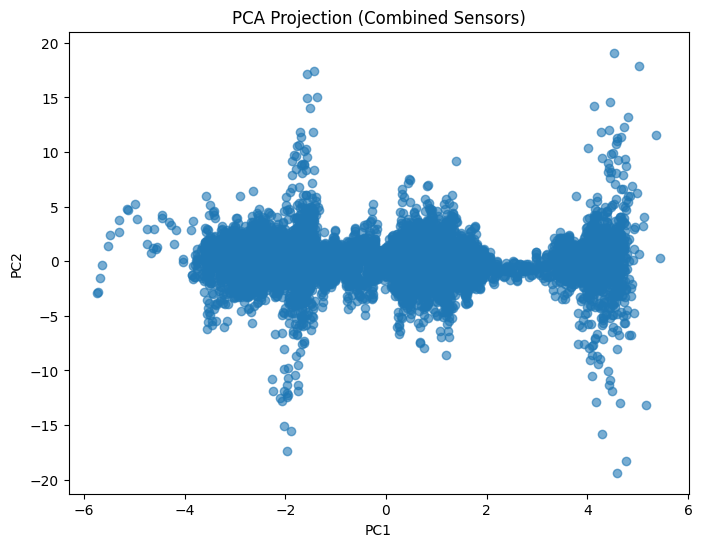

Silhouette Score (Combined): 0.12334506283636243

ACC Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



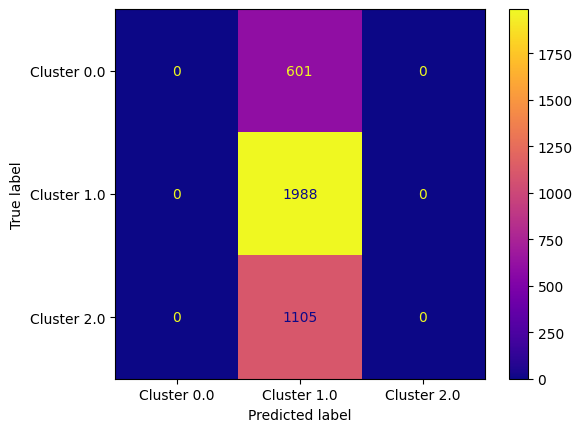

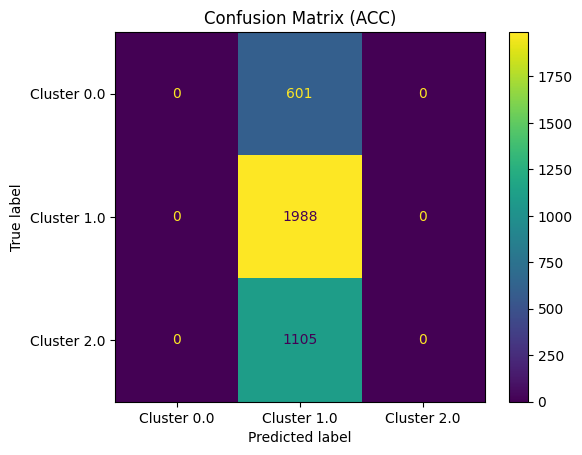


GYRO Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



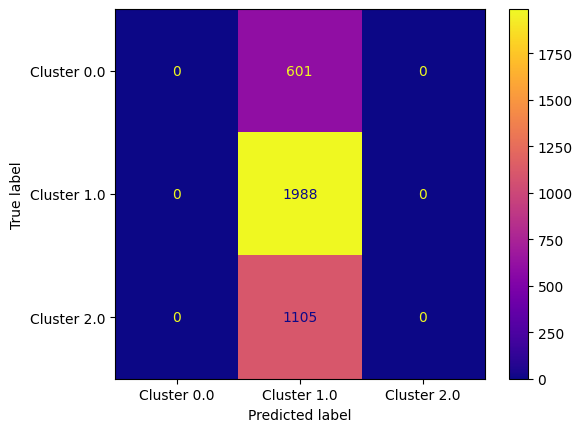

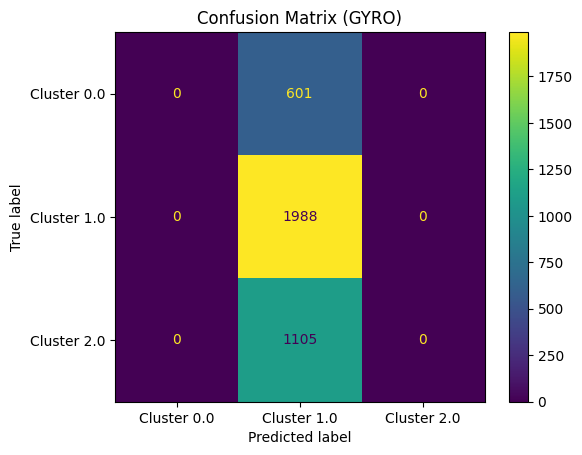


MAG Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



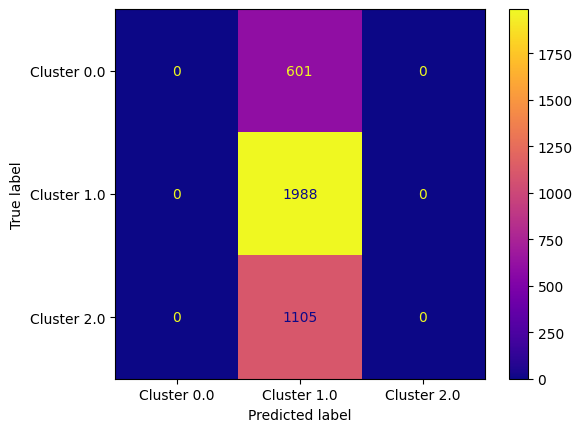

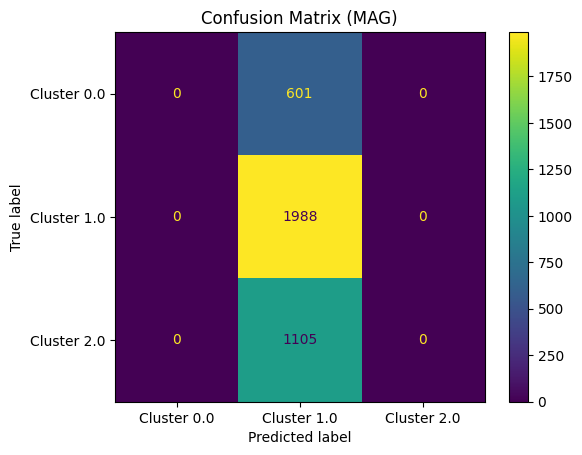


TOTACC Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       0.00      0.00      0.00       601
 Cluster 1.0       0.54      1.00      0.70      1988
 Cluster 2.0       0.00      0.00      0.00      1105

    accuracy                           0.54      3694
   macro avg       0.18      0.33      0.23      3694
weighted avg       0.29      0.54      0.38      3694



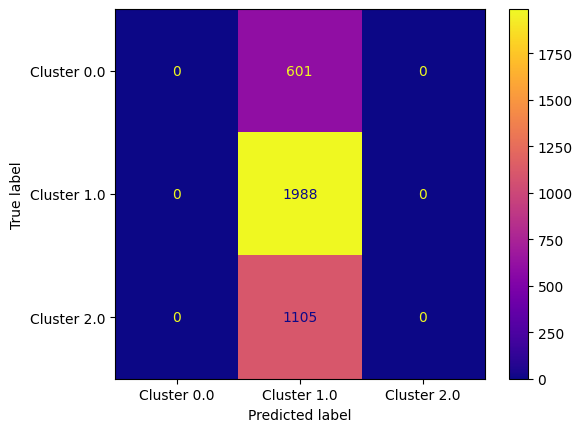

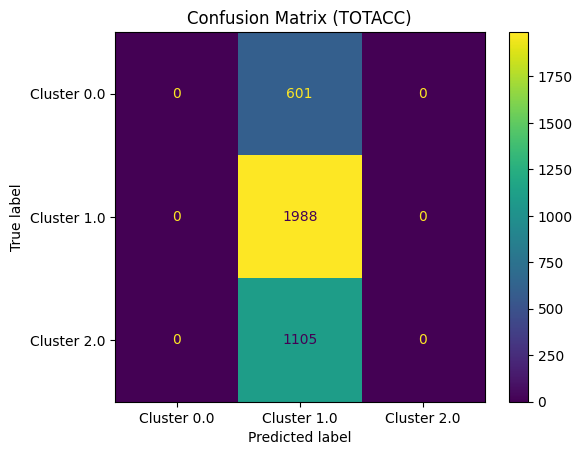


Combined Sensors Classification Report:
              precision    recall  f1-score   support

 Cluster 0.0       1.00      0.99      1.00       601
 Cluster 1.0       1.00      1.00      1.00      1988
 Cluster 2.0       1.00      1.00      1.00      1105

    accuracy                           1.00      3694
   macro avg       1.00      1.00      1.00      3694
weighted avg       1.00      1.00      1.00      3694



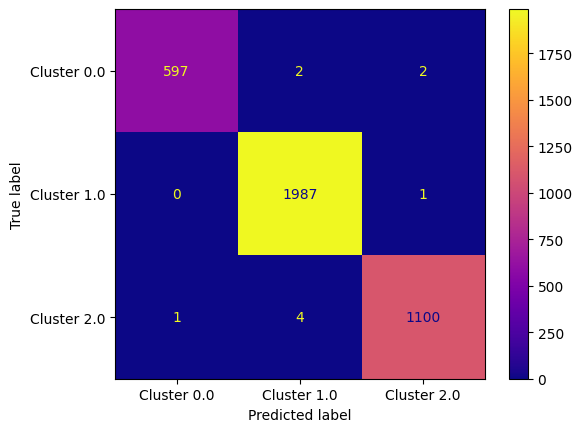

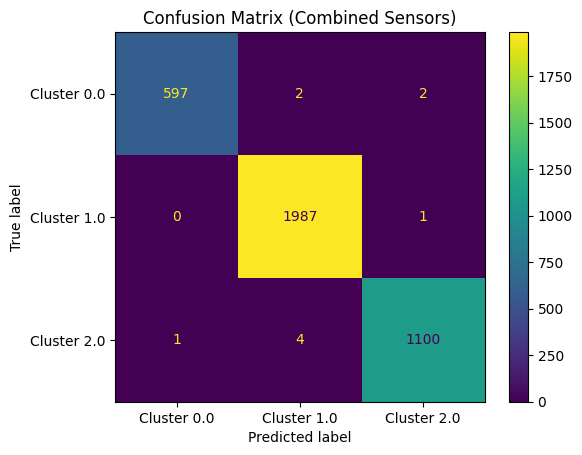

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.model_selection import train_test_split

def run_core_and_combined_analysis(acc_df, gyro_df, mag_df, totacc_df):
    # Normalize column names
    def normalize_axes(df, prefix):
        mapping = {}
        for c in df.columns:
            lc = c.lower()
            if lc in ['x','accx','gyrox','magx','totaccx']:
                mapping[c] = f"{prefix}_x"
            elif lc in ['y','accy','gyroy','magy','totaccy']:
                mapping[c] = f"{prefix}_y"
            elif lc in ['z','accz','gyroz','magz','totaccz']:
                mapping[c] = f"{prefix}_z"
            elif lc == 'seconds_elapsed':
                mapping[c] = 'seconds_elapsed'
        return df.rename(columns=mapping)

    acc_df = normalize_axes(acc_df, "acc")
    gyro_df = normalize_axes(gyro_df, "gyro")
    mag_df = normalize_axes(mag_df, "mag")
    totacc_df = normalize_axes(totacc_df, "totacc")

    # Merge
    merged_df = pd.merge_asof(
        pd.merge_asof(
            pd.merge_asof(
                acc_df.sort_values("seconds_elapsed"),
                gyro_df.sort_values("seconds_elapsed"),
                on="seconds_elapsed", direction="nearest"
            ),
            mag_df.sort_values("seconds_elapsed"),
            on="seconds_elapsed", direction="nearest"
        ),
        totacc_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed", direction="nearest"
    )

    # Features
    features = [c for c in merged_df.columns if any(c.startswith(s) for s in ['acc','gyro','mag','totacc'])]
    X = merged_df[features].apply(pd.to_numeric, errors='coerce').dropna()

    if X.empty:
        print("No numeric data available after cleaning.")
        return

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA (combined)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA Projection (Combined Sensors)")
    plt.show()

    # KMeans clustering (combined)
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    merged_df.loc[X.index,'cluster'] = clusters
    print("Silhouette Score (Combined):", silhouette_score(X_scaled, clusters))

    # Helper for classification
    def classify_and_report(X_data, y_data, title):
        if len(np.unique(y_data)) > 1:
            X_train, X_test, y_train, y_test = train_test_split(X_data, y_data[:len(X_data)], test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            print(f"\n{title} Classification Report:")
            print(classification_report(y_test, y_pred, target_names=[f"Cluster {i}" for i in np.unique(y_data)], zero_division=0))
            ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=[f"Cluster {i}" for i in np.unique(y_data)], cmap="plasma").plot()
            plt.title(f"Confusion Matrix ({title})")
            plt.show()
        else:
            print(f"\n{title} Classification Report: Only one cluster present")

    # Per-sensor classification reports
    y_cluster = merged_df['cluster'].values
    for sensor in ['acc','gyro','mag','totacc']:
        cols = [c for c in merged_df.columns if c.startswith(sensor+'_')]
        X_sensor = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()
        if not X_sensor.empty:
            classify_and_report(X_sensor, y_cluster[:len(X_sensor)], sensor.upper())

    # Combined classification report
    classify_and_report(X_scaled, y_cluster, "Combined Sensors")
run_core_and_combined_analysis(acc_df, gyro_df, mag_df, totacc_df)


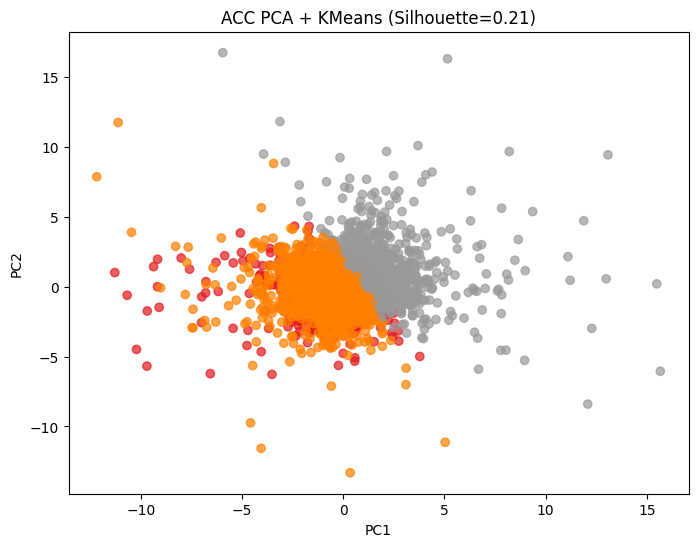

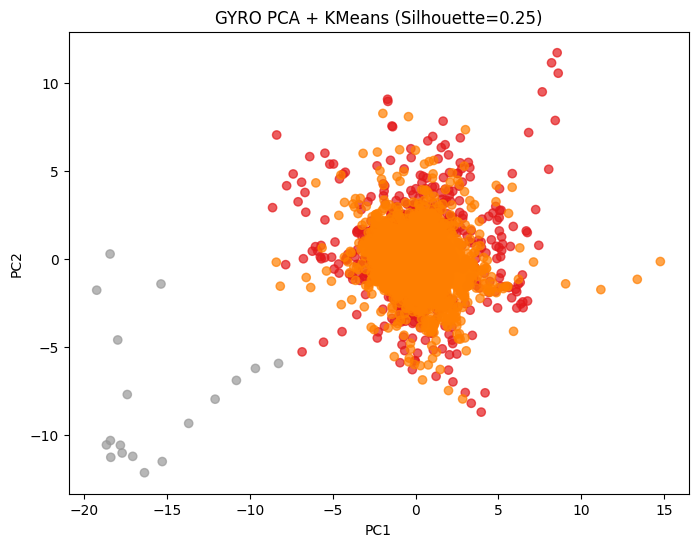

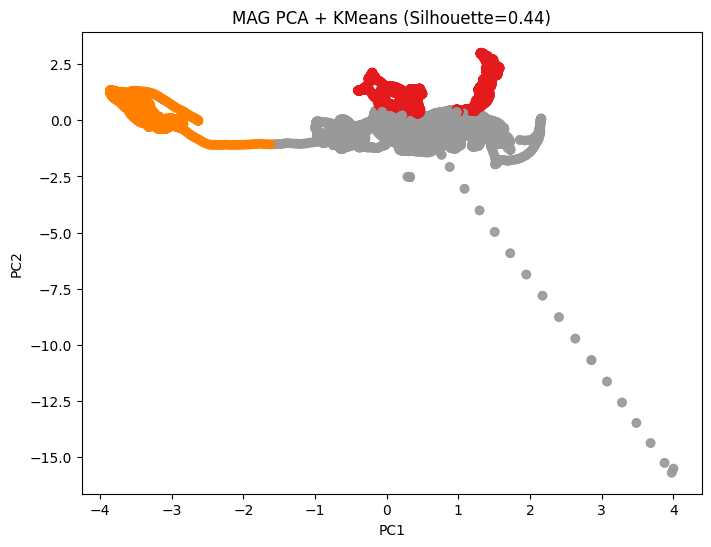

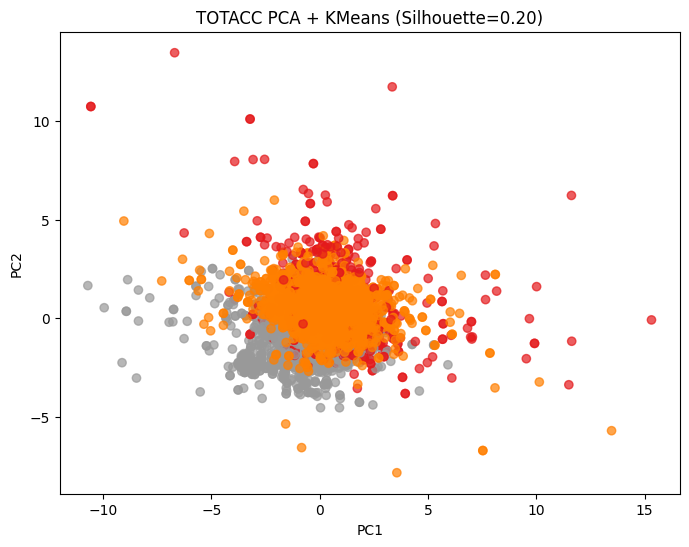

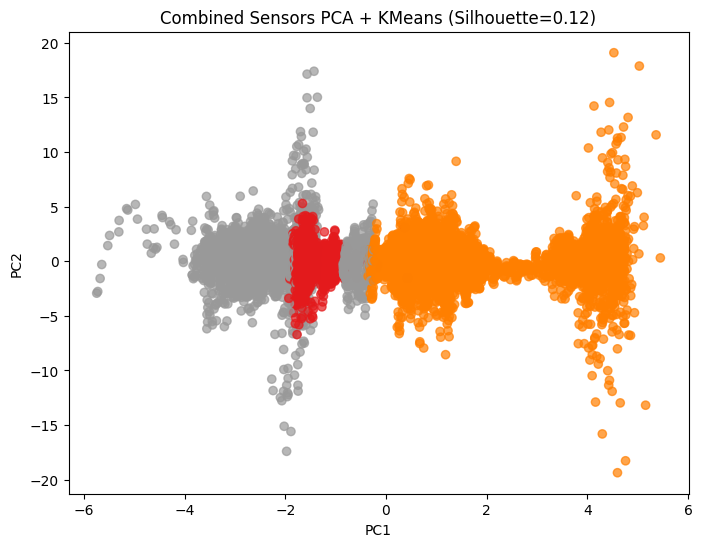

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def run_separate_and_combined_kmeans(acc_df, gyro_df, mag_df, totacc_df):
    # Normalize column names
    def normalize_axes(df, prefix):
        mapping = {}
        for c in df.columns:
            lc = c.lower()
            if lc in ['x','accx','gyrox','magx','totaccx']:
                mapping[c] = f"{prefix}_x"
            elif lc in ['y','accy','gyroy','magy','totaccy']:
                mapping[c] = f"{prefix}_y"
            elif lc in ['z','accz','gyroz','magz','totaccz']:
                mapping[c] = f"{prefix}_z"
            elif lc == 'seconds_elapsed':
                mapping[c] = 'seconds_elapsed'
        return df.rename(columns=mapping)

    acc_df = normalize_axes(acc_df, "acc")
    gyro_df = normalize_axes(gyro_df, "gyro")
    mag_df = normalize_axes(mag_df, "mag")
    totacc_df = normalize_axes(totacc_df, "totacc")

    # Merge all four datasets
    merged_df = pd.merge_asof(
        pd.merge_asof(
            pd.merge_asof(
                acc_df.sort_values("seconds_elapsed"),
                gyro_df.sort_values("seconds_elapsed"),
                on="seconds_elapsed", direction="nearest"
            ),
            mag_df.sort_values("seconds_elapsed"),
            on="seconds_elapsed", direction="nearest"
        ),
        totacc_df.sort_values("seconds_elapsed"),
        on="seconds_elapsed", direction="nearest"
    )

    # Helper: PCA + KMeans plot
    def pca_kmeans_plot(X, title):
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X.dropna())
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        kmeans = KMeans(n_clusters=3, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, clusters)

        plt.figure(figsize=(8,6))
        plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="Set1", alpha=0.7)
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.title(f"{title} PCA + KMeans (Silhouette={sil:.2f})")
        plt.show()

    # Separate PCA + KMeans for each sensor
    for sensor in ['acc','gyro','mag','totacc']:
        cols = [c for c in merged_df.columns if c.startswith(sensor+'_')]
        if cols:
            X_sensor = merged_df[cols].apply(pd.to_numeric, errors='coerce').dropna()
            if not X_sensor.empty:
                pca_kmeans_plot(X_sensor, sensor.upper())

    # Combined PCA + KMeans for all sensors
    features = [c for c in merged_df.columns if any(c.startswith(s) for s in ['acc','gyro','mag','totacc'])]
    X_combined = merged_df[features].apply(pd.to_numeric, errors='coerce').dropna()
    if not X_combined.empty:
        pca_kmeans_plot(X_combined, "Combined Sensors")
run_separate_and_combined_kmeans(acc_df, gyro_df, mag_df, totacc_df)
